# Validate the plate-position correction

`0.fit_position_correction.ipynb` fits the tilt on all platemaps, so it cannot show that the correction works.
Here we test the correction on data the tilt did not see.

**Question:** after the correction, can a classifier still tell which plate row a compound well came from?

**Design (leave one platemap out):**

1. Fit the tilt on ten platemaps and correct all eleven (the held-out platemap uses its own shrunk amplitude).
2. Train a classifier to predict the well row from compound-well profiles of the ten training platemaps.
3. Predict the row of the held-out platemap's wells and score it with the area under the ROC curve (AUC), where 0.5 is chance.
4. Compare three classifiers, all scored on the held-out platemap:
   1. **Raw:** trained and tested on uncorrected profiles.
   2. **Corrected:** trained and tested on corrected profiles.
   3. **Shuffled:** trained on uncorrected profiles with the row labels shuffled (repeated several times), which gives the chance-level floor.

**Expectation:** the raw classifier predicts row well (high AUC), the shuffled classifier sits at chance, and the corrected classifier moves from the raw level toward the shuffled level.

The held-out platemap's compounds are never in the training set, so the classifier cannot use compound identity.
The held-out platemap's amplitude is still estimated from its own compound wells, so this is not fully out-of-sample (one number per platemap).

## Import libraries

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sys.path.append("../../utils")
import position_correction_utils as pcu

## Set paths and variables

In [2]:
output_dir = pathlib.Path(".")
figure_dir = output_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# well-level summary written by 0.fit_position_correction.ipynb
well_medians_cache = output_dir / "well_medians.parquet"
if not well_medians_cache.exists():
    raise FileNotFoundError(
        f"{well_medians_cache} not found. Run 0.fit_position_correction.ipynb first."
    )

n_shuffles = 10  # shuffled-label repetitions per held-out platemap
n_components = 50  # PCA components fed to the classifier
min_cells = 50  # minimum cells for a well to be used

## Load compound wells

In [3]:
well_medians = pd.read_parquet(well_medians_cache)
meta_cols = ["plate", "platemap", "well", "treatment", "cell_type", "n"]
features = [c for c in well_medians.columns if c not in meta_cols]

wells = well_medians[
    (well_medians["n"] >= min_cells)
    & ~well_medians["treatment"].isin(pcu.CONTROL_TREATMENTS)
].reset_index(drop=True)
wells["row"], wells["col"] = pcu.well_index(wells["well"])
profiles = wells[features].to_numpy(float)
platemaps = sorted(wells["platemap"].unique())

print("Compound wells:", len(wells))
print(wells["row"].map(dict(enumerate(pcu.ROWS))).value_counts().sort_index().to_dict())

Compound wells: 1505
{'B': 158, 'C': 297, 'D': 284, 'E': 180, 'F': 280, 'G': 306}


## Define the classifier and the scoring

A multinomial logistic regression predicts the row (B to G) from standardized, PCA-reduced profiles.
Class weights are balanced because row B has fewer wells.
We report the macro one-vs-rest AUC over the six rows and the AUC for row B against the rest.

In [4]:
n_rows = len(pcu.ROWS)


def predict_rows(train_x, train_y, test_x, seed):
    """Train a row classifier and predict the row probabilities of new wells.

    The model standardizes the profiles, reduces them to ``n_components`` principal
    components, and fits a class-balanced multinomial logistic regression of the plate
    row.

    Parameters
    ----------
    train_x : np.ndarray
        Training wells by features.
    train_y : np.ndarray
        Row index (0 to 5, rows B to G) of each training well.
    test_x : np.ndarray
        Wells to predict, with the same features as ``train_x``.
    seed : int
        Random seed of the PCA.

    Returns
    -------
    np.ndarray
        Probabilities with shape ``(len(test_x), n_rows)``.
        The columns follow the rows B to G, and a row that is absent from ``train_y``
        gets probability 0.
    """
    model = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=seed),
        LogisticRegression(max_iter=2000, class_weight="balanced"),
    )
    model.fit(train_x, train_y)
    probabilities = np.zeros((len(test_x), n_rows))
    probabilities[:, model.classes_] = model.predict_proba(test_x)
    return probabilities


def macro_auc(true_rows, probabilities):
    """Score row predictions with the macro-averaged one-vs-rest AUC.

    The AUC of each row against all other rows is computed first, and the six values
    are averaged with equal weight.
    A value of 0.5 is chance level.

    Parameters
    ----------
    true_rows : np.ndarray
        True row index (0 to 5) of each well.
    probabilities : np.ndarray
        Predicted probabilities with shape ``(n_wells, n_rows)`` from ``predict_rows``.

    Returns
    -------
    float
        Macro-averaged AUC over the six rows.
    """
    return roc_auc_score(
        true_rows,
        probabilities,
        multi_class="ovr",
        average="macro",
        labels=list(range(n_rows)),
    )


def row_b_auc(true_rows, probabilities):
    """Score how well the predicted probability of row B separates row B from the rest.

    Parameters
    ----------
    true_rows : np.ndarray
        True row index (0 to 5) of each well; row B is 0.
    probabilities : np.ndarray
        Predicted probabilities with shape ``(n_wells, n_rows)`` from ``predict_rows``.

    Returns
    -------
    float
        AUC of the row B probability for row B wells against all other wells.
        A value of 0.5 is chance level.
    """
    return roc_auc_score(true_rows == 0, probabilities[:, 0])

## Run the leave-one-platemap-out validation

For each held-out platemap, the tilt is fit without it.
Training platemaps use their own shrunk amplitudes from that fit.

In [5]:
rng = np.random.default_rng(0)
predictions = {"raw": [], "corrected": []}
shuffled = [[] for _ in range(n_shuffles)]  # classifier 3, one list per repetition
truth = []
fold_platemap = []

for held_out in platemaps:
    fit = pcu.fit_position_correction(well_medians, features, hold_out_platemap=held_out)
    amplitude = {p: pcu.shrink_amplitude(fit["raw_amplitudes"], p) for p in platemaps}
    amplitude[held_out] = fit["amplitudes"][held_out]

    # correct every compound well with the amplitude of its own platemap
    corrected = profiles.copy()
    for platemap in platemaps:
        idx = np.where(wells["platemap"] == platemap)[0]
        corrected[idx] -= amplitude[platemap] * pcu.tilt(
            fit["coef"], fit["center"], wells["row"].to_numpy()[idx], wells["col"].to_numpy()[idx]
        )

    train = (wells["platemap"] != held_out).to_numpy()
    train_rows = wells["row"].to_numpy()[train]
    test_rows = wells["row"].to_numpy()[~train]
    truth.append(test_rows)
    fold_platemap.append(np.full(len(test_rows), held_out))

    # classifier 1: raw profiles
    predictions["raw"].append(predict_rows(profiles[train], train_rows, profiles[~train], seed=0))
    # classifier 2: corrected profiles
    predictions["corrected"].append(
        predict_rows(corrected[train], train_rows, corrected[~train], seed=0)
    )
    # classifier 3: raw profiles, shuffled training labels
    for repetition in range(n_shuffles):
        permuted = rng.permutation(train_rows)
        shuffled[repetition].append(
            predict_rows(profiles[train], permuted, profiles[~train], seed=repetition)
        )
    print(f"Held-out platemap {held_out} done")

truth = np.concatenate(truth)
fold_platemap = np.concatenate(fold_platemap)

Held-out platemap 1 done


Held-out platemap 2 done


Held-out platemap 3 done


Held-out platemap 4 done


Held-out platemap 5 done


...

Held-out platemap 7 done


Held-out platemap 8 done


Held-out platemap 9 done


Held-out platemap 10 done


Held-out platemap 11 done


## Compare held-out performance

The AUC is computed on the pooled held-out predictions of all eleven platemaps.
For the shuffled classifier we report the mean and standard deviation over its repetitions.
"Excess AUC removed" is how far correction moves the AUC from the raw level toward the shuffled level: `(raw - corrected) / (raw - shuffled)`.
A value of 1 means the corrected profiles are as unpredictable as shuffled labels, and 0 means no change.

In [6]:
raw_probabilities = np.vstack(predictions["raw"])
corrected_probabilities = np.vstack(predictions["corrected"])
shuffled_macro = np.array([macro_auc(truth, np.vstack(s)) for s in shuffled])
shuffled_b = np.array([row_b_auc(truth, np.vstack(s)) for s in shuffled])

results = pd.DataFrame(
    {
        "macro_auc": [
            macro_auc(truth, raw_probabilities),
            macro_auc(truth, corrected_probabilities),
            shuffled_macro.mean(),
        ],
        "row_b_auc": [
            row_b_auc(truth, raw_probabilities),
            row_b_auc(truth, corrected_probabilities),
            shuffled_b.mean(),
        ],
        "macro_auc_sd": [np.nan, np.nan, shuffled_macro.std()],
        "row_b_auc_sd": [np.nan, np.nan, shuffled_b.std()],
    },
    index=["1. raw", "2. corrected", "3. shuffled labels"],
)
results.round(3).to_csv(output_dir / "row_prediction_validation.csv")
print(results.round(3).to_string())

for label, column in [("macro AUC", "macro_auc"), ("row B AUC", "row_b_auc")]:
    raw, corrected_auc, floor = results[column]
    print(
        f"{label}: raw {raw:.3f}, corrected {corrected_auc:.3f}, shuffled {floor:.3f}; "
        f"excess AUC removed {(raw - corrected_auc) / (raw - floor):.2f}"
    )

                    macro_auc  row_b_auc  macro_auc_sd  row_b_auc_sd
1. raw                  0.760      0.938           NaN           NaN
2. corrected            0.521      0.565           NaN           NaN
3. shuffled labels      0.494      0.491         0.018         0.054
macro AUC: raw 0.760, corrected 0.521, shuffled 0.494; excess AUC removed 0.90
row B AUC: raw 0.938, corrected 0.565, shuffled 0.491; excess AUC removed 0.83


## Per held-out platemap

Row B against the rest, one line per held-out platemap.
Platemaps with fewer than two wells in either class are skipped.

 platemap   raw  corrected  shuffled
        1 0.831      0.524     0.578
        2 0.989      0.658     0.421
        3 0.839      0.548     0.457
        4 0.953      0.802     0.491
        5 0.964      0.221     0.556
        6 0.990      0.543     0.497
        7 0.986      0.497     0.478
        8 0.996      0.552     0.577
        9 0.755      0.643     0.427
       10 0.993      0.611     0.567
       11 0.942      0.231     0.446


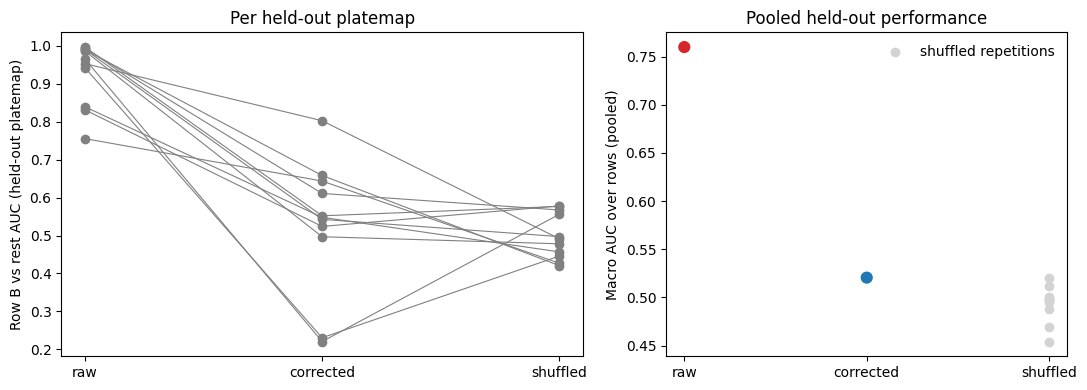

In [7]:
per_platemap = []
for platemap in platemaps:
    keep = fold_platemap == platemap
    if (truth[keep] == 0).sum() < 2 or (truth[keep] != 0).sum() < 2:
        continue
    per_platemap.append(
        {
            "platemap": platemap,
            "raw": row_b_auc(truth[keep], raw_probabilities[keep]),
            "corrected": row_b_auc(truth[keep], corrected_probabilities[keep]),
            "shuffled": np.mean(
                [row_b_auc(truth[keep], np.vstack(s)[keep]) for s in shuffled]
            ),
        }
    )
per_platemap = pd.DataFrame(per_platemap)
per_platemap.round(3).to_csv(output_dir / "row_prediction_per_platemap.csv", index=False)
print(per_platemap.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.3, 1]})
for _, record in per_platemap.iterrows():
    axes[0].plot(
        [0, 1, 2],
        [record["raw"], record["corrected"], record["shuffled"]],
        color="grey",
        lw=0.8,
        marker="o",
    )
axes[0].set_xticks([0, 1, 2], labels=["raw", "corrected", "shuffled"])
axes[0].set_ylabel("Row B vs rest AUC (held-out platemap)")
axes[0].set_title("Per held-out platemap")

axes[1].scatter([2] * n_shuffles, shuffled_macro, color="lightgrey", label="shuffled repetitions")
axes[1].scatter([0, 1], results["macro_auc"].iloc[:2], color=["tab:red", "tab:blue"], s=60, zorder=3)
axes[1].set_xticks([0, 1, 2], labels=["raw", "corrected", "shuffled"])
axes[1].set_ylabel("Macro AUC over rows (pooled)")
axes[1].set_title("Pooled held-out performance")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(figure_dir / "row_prediction_validation.png", dpi=120)
plt.show()

## Check that the method recovers a known tilt

We simulate 11 platemaps of 4 replicate plates each with a known tilt, a random amplitude per platemap, random real compound effects, and measurement noise.
The fit should recover the tilt and the amplitudes without removing the compound effects.

In [8]:
rng = np.random.default_rng(1)
n_features = 200
well_names = [f"{r}{c:02d}" for r in pcu.ROWS for c in range(2, 12)]
control_wells = [f"{r}{c:02d}" for r in "BE" for c in (2, 5, 8, 11)]
sim_rows, sim_cols = pcu.well_index(well_names)
is_control_well = np.array([w in control_wells for w in well_names])

true_row = rng.normal(0, 1, (6, n_features)) * np.array([3.0, 0.3, 0.1, 0.3, 0.2, 0.2])[:, None]
true_col = rng.normal(0, 0.3, (10, n_features))
true_tilt = true_row[sim_rows] + true_col[sim_cols]
true_tilt -= true_tilt[~is_control_well].mean(axis=0)
true_amplitude = dict(zip(range(1, 12), rng.normal(1, 0.2, 11), strict=True))

sim_features = [f"f{j}" for j in range(n_features)]
records = []
for platemap in range(1, 12):
    compound_effect = rng.normal(0, 1.0, (len(well_names), n_features))
    for replicate in range(4):
        noise = rng.normal(0, 0.3, (len(well_names), n_features))
        profile = true_amplitude[platemap] * true_tilt + noise
        profile[~is_control_well] += compound_effect[~is_control_well]
        table = pd.DataFrame(profile, columns=sim_features)
        table.insert(0, "n", 150)
        table.insert(0, "cell_type", ["healthy" if w[0] == "B" else "failing" for w in well_names])
        table.insert(
            0,
            "treatment",
            ["DMSO" if c else f"compound_{platemap}_{i}" for i, c in enumerate(is_control_well)],
        )
        table.insert(0, "well", well_names)
        table.insert(0, "platemap", platemap)
        table.insert(0, "plate", f"sim_{platemap}_{replicate}")
        records.append(table)
simulated = pd.concat(records, ignore_index=True)

sim_fit = pcu.fit_position_correction(simulated, sim_features)
estimated_tilt = pcu.tilt(sim_fit["coef"], sim_fit["center"], sim_rows, sim_cols)
cosines = [
    estimated_tilt[i] @ true_tilt[i] / np.linalg.norm(estimated_tilt[i]) / np.linalg.norm(true_tilt[i])
    for i in range(len(well_names))
]
estimated_amplitude = np.array([sim_fit["amplitudes"][p] for p in range(1, 12)])
print(f"Tilt recovery: median cosine over positions {np.median(cosines):.3f} (min {np.min(cosines):.3f})")
print(
    "Amplitude recovery: correlation "
    f"{np.corrcoef(estimated_amplitude, list(true_amplitude.values()))[0, 1]:.2f}"
)

Tilt recovery: median cosine over positions 0.954 (min 0.935)
Amplitude recovery: correlation 1.00


## What this does and does not show

- A drop toward the shuffled-label level means the corrected profiles carry less information about plate row, including in directions the correction did not subtract.
- It does not show that the remaining signal is the right one, or that position moves healthy and failing cells equally.
- Shuffled labels sit at chance by construction, so being close to them is the target, and "close enough" is a judgment.
- The held-out platemap's amplitude comes from its own compounds, so the check is not fully out-of-sample.